In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
LPF = np.array([1/np.sqrt(2), 1/np.sqrt(2)])
HPF = np.array([-1/np.sqrt(2), (1/np.sqrt(2))])

def convo_h(image, kernel):
    ukuran_kernel = len(kernel)
    pad_width = ukuran_kernel // 2
    padd = np.pad(image, ((0, 0), (pad_width, pad_width)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))

    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += padd[i][j + x] * kernel[x]
    return conv

def convo_h(image, kernel):
    ukuran_kernel = len(kernel)
    pad_width = ukuran_kernel // 2

    padd = np.pad(
        image,
        ((0,0),(pad_width,pad_width)),
        mode='constant'
    )

    conv = np.zeros(image.shape)

    for i in range(conv.shape[0]):
        for j in range(conv.shape[1]):
            for x in range(ukuran_kernel):
                conv[i,j] += (
                    padd[i,j+x]
                    * kernel[ukuran_kernel-1-x]
                )

    return conv

def convo_v(image, kernel):
    ukuran_kernel = len(kernel)
    pad_width = ukuran_kernel // 2
    padd = np.pad(image, ((pad_width, pad_width), (0, 0)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))
    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += padd[i + x][j] * kernel[x]
    return conv

def downsampling_h(image):
    downsampled = np.zeros((image.shape[0], image.shape[1] // 2))
    for i in range(len(downsampled)):
        indeks = 0
        for j in range(len(downsampled[i])):
            downsampled[i][j] = image[i][indeks]
            indeks += 2
    return downsampled

def downsampling_v(image):
    baris = int(image.shape[0] / 2)
    kolom = int(image.shape[1])
    downsampled = np.zeros((baris, kolom))
    indeks = 0
    for i in range(baris):
        for j in range(kolom):
            downsampled[i][j] = image[indeks][j]
        indeks += 2
    return downsampled

def normalisasi(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val == min_val:
        return np.zeros(image.shape)
    return (image - min_val) / (max_val - min_val) * 255

def wavelet(image):
    # LL (Approximation)
    konvolusi1 = convo_h(image, LPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, LPF)
    approximation = downsampling_v(konvolusi2)
    approximation = normalisasi(approximation)

    # LH (Horizontal Detail)
    konvolusi1 = convo_h(image, LPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, HPF)
    horizontal = downsampling_v(konvolusi2)
    horizontal = normalisasi(horizontal)

    # HL (Vertical Detail)
    konvolusi1 = convo_h(image, HPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, LPF)
    vertikal = downsampling_v(konvolusi2)
    vertikal = normalisasi(vertikal)

    # HH (Diagonal Detail)
    konvolusi1 = convo_h(image, HPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, HPF)
    diagonal = downsampling_v(konvolusi2)
    diagonal = normalisasi(diagonal)

    return (approximation, horizontal, vertikal, diagonal)




In [3]:
def upsampling_v(image):
    upsampled = np.zeros((image.shape[0] * 2, image.shape[1]))
    for i in range(len(image)):
        for j in range(len(image[i])):
            upsampled[i * 2][j] = image[i][j]
    return upsampled

def upsampling_h(image):
    upsampled = np.zeros((image.shape[0], image.shape[1] * 2))
    for i in range(len(image)): 
        for j in range(len(image[i])):
            upsampled[i][j * 2] = image[i][j]
    return upsampled

def rekonstruksi(LL, LH, HL, HH, LPF, HPF):
    upsampling = upsampling_v(LL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(LH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiL2 = convo_h(upsampling, LPF)

    upsampling = upsampling_v(HL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(HH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiH2 = convo_h(upsampling, HPF)

    hasil = konvolusiL2 + konvolusiH2
    return hasil

In [4]:
def thresholding(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if img[i,j] >= batas:
                canvas[i,j] = 255
            elif img[i,j] <= batas:
                canvas[i,j] = 0
    return canvas

In [5]:
kernel5 = np.array ([[0, 0, 1, 0, 0],
                     [0, 1, 1, 1, 0],
                     [1, 1, 1, 1, 1],
                     [0, 1, 1, 1, 0],
                     [0, 0, 1, 0, 0]])


In [6]:
def Dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))

    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i+k-center, j+l-center] = 255
            else:
                if hasil[i, j] != 255:
                    hasil[i, j] = 0

    return hasil


def Erosi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)

    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i+k-center, j+l-center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255

    return hasil

def closing(image, kernel):
    return Erosi(Dilasi(image, kernel), kernel)


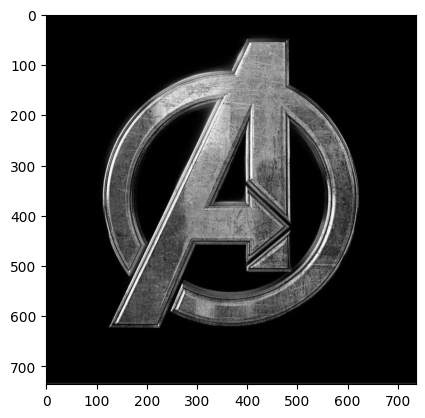

In [7]:
d_asli = cv2.imread('doomsday.jpg')
d_gray = cv2.cvtColor(d_asli, cv2.COLOR_BGR2GRAY)

plt.imshow(d_gray, cmap='gray')
plt.show()

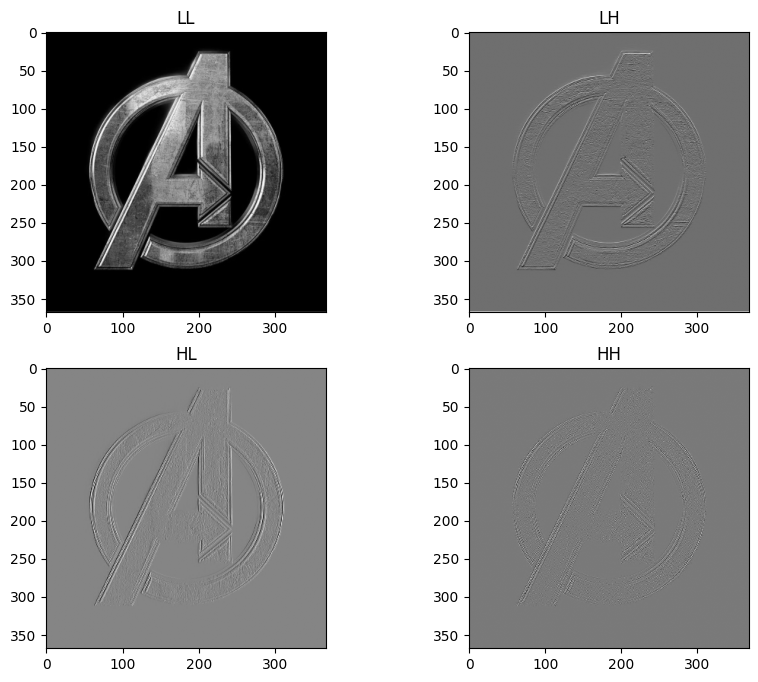

In [8]:
d_ll, d_lh, d_hl, d_hh = wavelet(d_gray)

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.imshow(d_ll, cmap='gray')
plt.title('LL')

plt.subplot(2,2,2)
plt.imshow(d_lh, cmap='gray')
plt.title('LH')

plt.subplot(2,2,3)
plt.imshow(d_hl, cmap='gray')
plt.title('HL')

plt.subplot(2,2,4)
plt.imshow(d_hh, cmap='gray')
plt.title('HH')
plt.show()

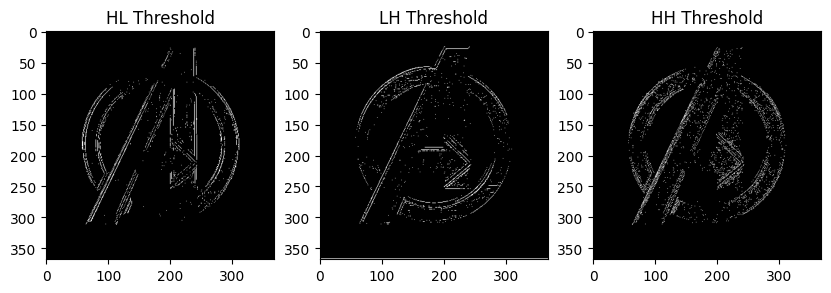

In [9]:
hl_thres = thresholding(d_hl, 160)
lh_thres = thresholding(d_lh, 140)
hh_thres = thresholding(d_hh, 145)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(hl_thres, cmap='gray')
plt.title('HL Threshold')

plt.subplot(1,3,2)
plt.imshow(lh_thres, cmap='gray')
plt.title('LH Threshold')

plt.subplot(1,3,3)
plt.imshow(hh_thres, cmap='gray')
plt.title('HH Threshold')

plt.show()

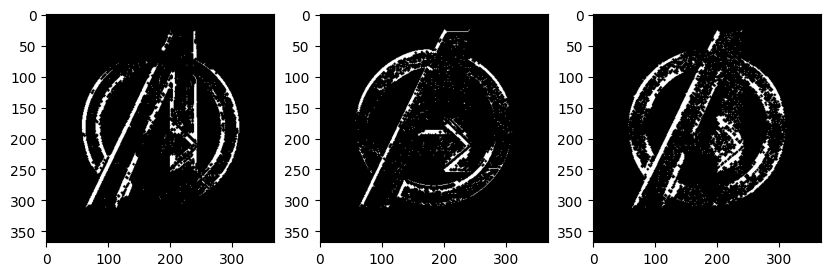

In [10]:
hl_closing = closing(hl_thres, kernel5)
lh_closing = closing(lh_thres, kernel5)
hh_closing = closing(hh_thres, kernel5)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(hl_closing, cmap='gray')

plt.subplot(1,3,2)
plt.imshow(lh_closing, cmap='gray')

plt.subplot(1,3,3)
plt.imshow(hh_closing, cmap='gray')

plt.show()

Hasil operasi closingpada ketiga citra (HL, LH, dan HH) menunjukkan bahwa bagian-bagian putih yang sebelumnya terputus atau memiliki celah kecil menjadi lebih menyatu. Titik-titik hitam berukuran kecil yang berada di dalam area putih juga berkurang sehingga bentuk objek terlihat lebih utuh. Perubahan ini membuat pola pada citra menjadi lebih jelas dan tidak terlalu terpengaruh oleh gangguan kecil. Setelah proses ini, informasi penting pada citra tetap dipertahankan, tetapi bagian yang tidak diperlukan menjadi lebih sedikit sehingga citra lebih siap digunakan pada tahap rekonstruksi atau pengolahan berikutnya.


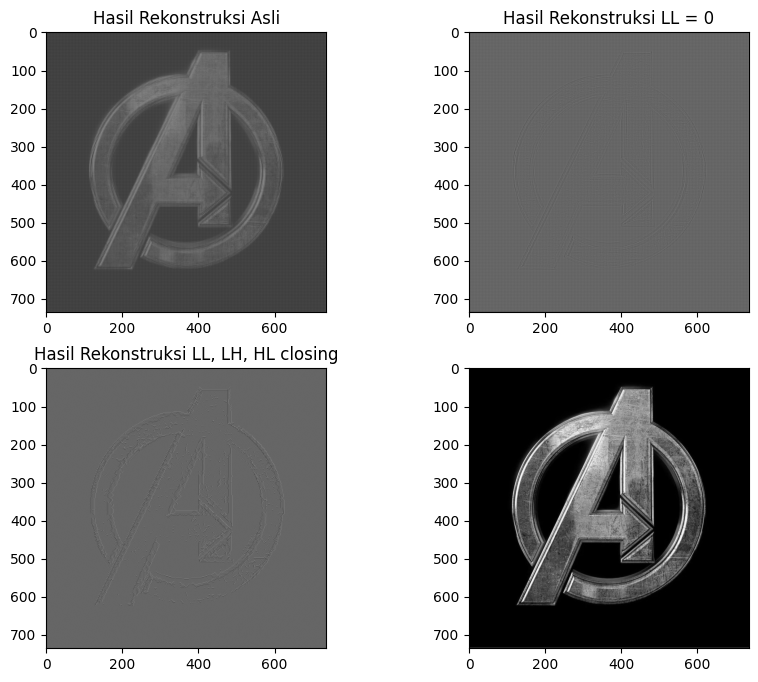

In [11]:
rekon_a = rekonstruksi(d_ll, d_lh, d_hl, d_hh,LPF,HPF)

d_ll0 = np.zeros_like(d_ll)
rekon_b = rekonstruksi(d_ll0, d_lh, d_hl, d_hh,LPF,HPF)

rekon_c = rekonstruksi(d_ll0, lh_closing, hl_closing, hh_closing,LPF,HPF)

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.imshow(rekon_a, cmap='gray')
plt.title('Hasil Rekonstruksi Asli')

plt.subplot(2,2,2)
plt.imshow(rekon_b, cmap='gray')
plt.title('Hasil Rekonstruksi LL = 0')

plt.subplot(2,2,3)
plt.imshow(rekon_c, cmap='gray')
plt.title('Hasil Rekonstruksi LL, LH, HL closing')

plt.subplot(2,2,4)
plt.imshow(d_gray, cmap='gray')
plt.show()

Gambar Hasil Rekonstruksi Asli menunjukkan citra yang dibangun kembali menggunakan seluruh komponen hasil dekomposisi sehingga bentuk dan informasi citra masih mendekati citra awal. Pada Hasil Rekonstruksi LL = 0, komponen LL dihilangkan sehingga informasi utama yang mewakili tingkat kecerahan umum citra tidak digunakan. Akibatnya, citra yang dihasilkan lebih menonjolkan perubahan intensitas dan detail-detail tertentu, sementara bentuk keseluruhan menjadi kurang jelas. Pada Hasil Rekonstruksi LL, LH, HL, HH Closing, komponen LL tetap dihilangkan, tetapi komponen detail telah melalui proses closing sebelum direkonstruksi. Hasilnya, beberapa bagian yang sebelumnya terputus menjadi lebih menyatu dan gangguan kecil berkurang. Jika dibandingkan dengan citra asli pada gambar terakhir, hasil rekonstruksi ini lebih menekankan detail yang telah diperbaiki dibandingkan mempertahankan seluruh informasi citra awal.
